In [294]:
import ipdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import cartopy
import cartopy.crs as ccrs
from endgame import hist2d
from eod import msg
import datetime
import glob
import os
from scipy.stats import binned_statistic_2d
from scipy import stats
import pickle as pkl
from scipy.stats import gaussian_kde, linregress
import importlib
from utils import u_statistics as u_stats
from COCOON import shear_scaling_plots
from GLOBAL import glob_util
importlib.reload(shear_scaling_plots)

%matplotlib inline

In [1]:
cd ..

/users/global/cornkle/pythonWorkspace/proj_CEH


In [295]:
REGIONS = glob_util.REGIONS

In [205]:
def read_env_var(root, var, region, year):
    path = f"{root}/{var}/region={region}/year={year}/part.parquet"

    print("Reading:")
    print(path)

    if not os.path.isfile(path):
        raise FileNotFoundError(path)

    df = pd.read_parquet(path,engine="fastparquet")
    df = df.rename(columns={"value": var})

    print("Regions inside file:", df["region"].unique())

    return df.copy()

In [206]:
ROOT = "/prj/global_water/MCS_5000km2_tables_v2/ERA5_storm_timeseries_TEST"

var = "q925"
region = "GPlains"
year = 2006

df = read_env_var(ROOT, var, region, year)

Reading:
/prj/global_water/MCS_5000km2_tables_v2/ERA5_storm_timeseries_TEST/q925/region=GPlains/year=2006/part.parquet
Regions inside file: ['GPlains']


In [207]:
print("Rows:", len(df))
print("Storms:", df["storm_id"].nunique())
print("Relative hours:", sorted(df["rel_hour"].unique()))

# print(
#     df.groupby("storm_id")["rel_hour"]
#       .apply(lambda x: sorted(x.unique()))
# )

Rows: 500
Storms: 50
Relative hours: [np.int64(-6), np.int64(-5), np.int64(-4), np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


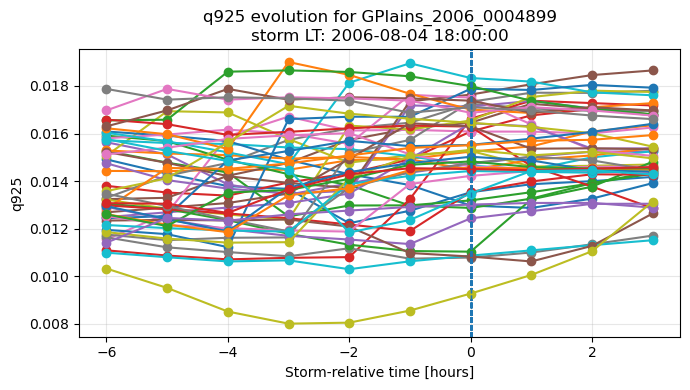

In [208]:
fig, ax = plt.subplots(figsize=(7, 4))

for ids in df["storm_id"].unique():
    
    storm_id = ids
    
    
    df["storm_utc_time"] = pd.to_datetime(df["storm_utc_time"])
    df["storm_lt_time"] = pd.to_datetime(df["storm_lt_time"])
    
    if "era_utc_time" in df.columns:
        df["era_utc_time"] = pd.to_datetime(df["era_utc_time"])
    
    if "era_lt_time" in df.columns:
        df["era_lt_time"] = pd.to_datetime(df["era_lt_time"])
    
    
    if storm_id is None:
        storm_id = df["storm_id"].iloc[0]
    
    sdf = df[df["storm_id"] == storm_id].copy()
    sdf = sdf.sort_values("rel_hour")
    
    # if len(sdf) == 0:
    #     raise ValueError(f"No data found for storm_id={storm_id}")
    
    # print("\nSelected storm:", storm_id)
    # print(sdf[["storm_id", "rel_hour", "era_lt_time", var]])
    
    
    
    
    ax.plot(sdf["rel_hour"], sdf[var], marker="o",)
    
    ax.axvline(0, linestyle="--", linewidth=1, label="storm time")

ax.set_xlabel("Storm-relative time [hours]")
ax.set_ylabel(var)
ax.set_title(
    f"{var} evolution for {storm_id}\n"  f"storm LT: {sdf['storm_lt_time'].iloc[0]}")

ax.grid(True, alpha=0.3)
#ax.legend()

plt.tight_layout()
plt.show()

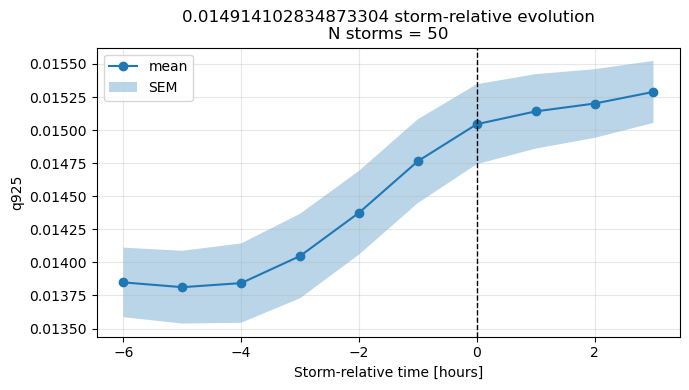

In [209]:
# Make sure rel_hour is numeric
df["rel_hour"] = pd.to_numeric(df["rel_hour"])

# ============================================================
# MEAN TIMESERIES
# ============================================================

mean_ts = (
    df.groupby("rel_hour")[var]
      .mean()
      .sort_index()
)

std_ts = (
    df.groupby("rel_hour")[var]
      .std()
      .sort_index()
)

n_ts = (
    df.groupby("rel_hour")[var]
      .count()
      .sort_index()
)

sem_ts = std_ts / np.sqrt(n_ts)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    mean_ts.index,
    mean_ts.values,
    marker="o",
    label="mean"
)

# optional uncertainty shading
ax.fill_between(
    mean_ts.index,
    mean_ts - sem_ts,
    mean_ts + sem_ts,
    alpha=0.3,
    label="SEM"
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
    color="k",
)

ax.set_xlabel("Storm-relative time [hours]")
ax.set_ylabel(var)

ax.set_title(
    f"{df[var].iloc[0]} storm-relative evolution\n"
    f"N storms = {df['storm_id'].nunique()}"
)

ax.grid(True, alpha=0.3)

ax.legend()

plt.tight_layout()
plt.show()

In [211]:
shear = read_env_var(ROOT, 'ushear100_650', region, year)
tcw = read_env_var(ROOT, 'tcwv', region, year)

shear = shear[shear['rel_hour']==-4]
tcw = tcw[tcw['rel_hour']==-4]

Reading:
/prj/global_water/MCS_5000km2_tables_v2/ERA5_storm_timeseries_TEST/ushear100_650/region=GPlains/year=2006/part.parquet
Regions inside file: ['GPlains']
Reading:
/prj/global_water/MCS_5000km2_tables_v2/ERA5_storm_timeseries_TEST/tcwv/region=GPlains/year=2006/part.parquet
Regions inside file: ['GPlains']


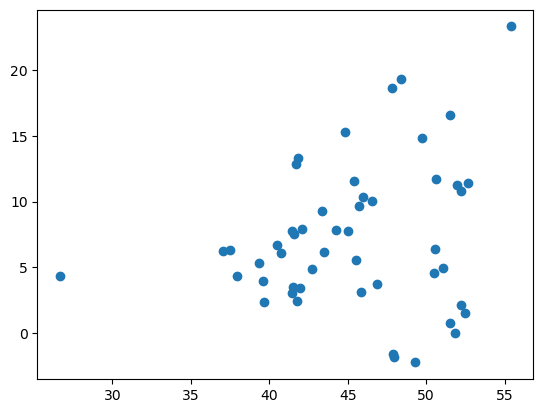

In [229]:
plt.scatter(tcw['tcwv'], shear['ushear100_650'])

In [232]:
static_path = '/prj/global_water/ERA5_global_0.7/static/era5_invariant_07deg_COCOON-study_regrid.nc'
ds_static = xr.open_dataset(static_path)

In [233]:
ds_static

<xarray.Dataset> Size: 2MB
Dimensions:                            (valid_time: 1, latitude: 186,
                                        longitude: 428)
Coordinates:
  * valid_time                         (valid_time) datetime64[ns] 8B 2020-01-01
  * latitude                           (latitude) float32 744B -60.0 ... 69.5
  * longitude                          (longitude) float32 2kB -139.0 ... 159.9
    number                             int32 4B ...
    expver                             object 8B ...
Data variables:
    lsm                                (valid_time, latitude, longitude) float32 318kB ...
    z                                  (valid_time, latitude, longitude) float32 318kB ...
    elevation                          (valid_time, latitude, longitude) float32 318kB ...
    sdfor                              (valid_time, latitude, longitude) float32 318kB ...
    slor                               (valid_time, latitude, longitude) float32 318kB ...
    topographic_complexity             (valid_time, latitude, longitude) float32 318kB ...
    topographic_complexity_sdfor_slor  (valid_time, latitude, longitude) float32 318kB ...
Attributes:
    regrid_method:     conservative
    description:       ERA5 invariant fields regridded to existing 0.7 degree...
    source_file:       /prj/global_water/ERA5_global_0.7/static/era5_invarian...
    target_grid_file:  /prj/global_water/ERA5_global_0.7/hourly/surface/conve...

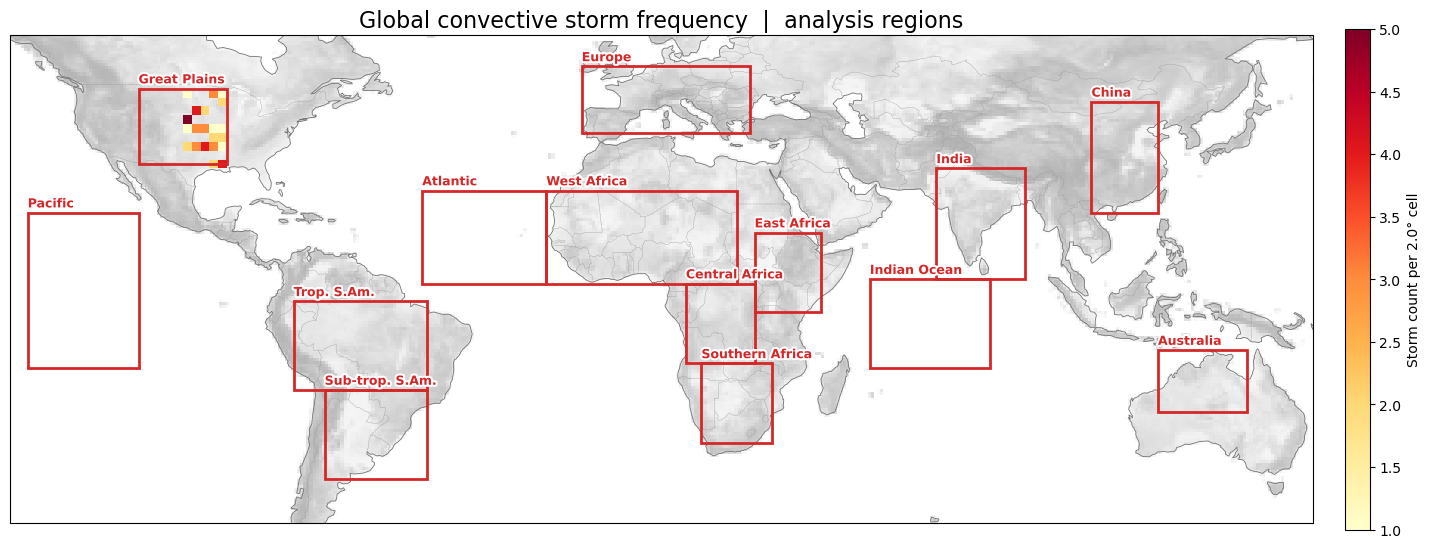

In [296]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe


# one row per storm if this is a variable-timeseries parquet
plot_df = df.drop_duplicates("storm_id").copy()

GRID_RES = 2.0

lon_bins = np.arange(-180, 181, GRID_RES)
lat_bins = np.arange(-60, 61, GRID_RES)

H, xedges, yedges = np.histogram2d(
    plot_df["tminlon"],
    plot_df["tminlat"],
    bins=[lon_bins, lat_bins],
)

H = H.T
H = np.ma.masked_where(H == 0, H)   # key bit: hide zero-storm cells

fig = plt.figure(figsize=(16, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
#ccrs.PlateCarree()
#ccrs.Robinson()
#ax.set_global()
ax.set_extent([-139, 155, -50, 60],crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="0.95")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.coastlines(linewidth=0.6, color="0.45")
ax.add_feature(cfeature.BORDERS, linewidth=0.25, edgecolor="0.6")

# ============================================================
# TOPOGRAPHIC COMPLEXITY BACKGROUND
# ============================================================

topo = ds_static["topographic_complexity"].squeeze()
topo_plot = np.log1p(topo)

# optional: log-transform because topo complexity
# is often extremely skewed


# weak greyscale background
ax.pcolormesh(
    topo["longitude"],
    topo["latitude"],
    topo_plot,
    transform=ccrs.PlateCarree(),
    cmap="Greys",
    shading="auto",
    alpha=0.28,
    zorder=0,
)

# ============================================================

cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(alpha=0.0)

mesh = ax.pcolormesh(
    xedges,
    yedges,
    H,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    shading="auto",
    zorder=2,
)

cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", shrink=0.65, pad=0.02)
cbar.set_label(f"Storm count per {GRID_RES}° cell")

ax.add_feature(cfeature.LAND, facecolor="0.96")

label_names = {
    "GPlains": "Great Plains",
    "Eur" : "Europe",
    "WAf": "West Africa",
    "SAf": "Southern Africa",
    "sub_SA": "Sub-trop. S.Am.",
    "trop_SA": "Trop. S.Am.",
    "CAf": "Central Africa",
    "EAf": "East Africa",
    "Atl": "Atlantic",
    "Pcf": "Pacific",
    "InO": "Indian Ocean",
    "china": "China",
    "india": "India",
    "australia": "Australia",
}

for region, info in REGIONS.items():
    lon1, lon2, lat1, lat2 = info[0]

    rect = Rectangle(
        (lon1, lat1),
        lon2 - lon1,
        lat2 - lat1,
        fill=False,
        linewidth=2.0,
        edgecolor="tab:red",
        transform=ccrs.PlateCarree(),
        zorder=5,
    )
    ax.add_patch(rect)

    ax.text(
        lon1,
        lat2 + 1.2,
        label_names.get(region, region),
        transform=ccrs.PlateCarree(),
        fontsize=9,
        fontweight="bold",
        color="tab:red",
        zorder=6,
        path_effects=[
            pe.withStroke(linewidth=3, foreground="white")
        ],
    )

ax.set_title("Global convective storm frequency  |  analysis regions", fontsize=16)
plt.tight_layout()
plt.show()